In [ ]:
#Data collected and created subset 
import os, shutil, pathlib

original_dir = pathlib.Path("Data/train/train")
new_base_dir = pathlib.Path("data/kaggle_dogs_vs_cats_small")

def make_subset(subset_name, start_index, end_index):
    for category in ("cat", "dog"):
        dir = new_base_dir / subset_name / category
        os.makedirs(dir)
        fnames = [f"{category}.{i}.jpg" for i in range(start_index, end_index)]
        for fname in fnames:
            shutil.copyfile(src=original_dir / fname,
                            dst=dir / fname)

make_subset("train", start_index=0, end_index=1000)
make_subset("validation", start_index=1000, end_index=1500)
make_subset("test", start_index=1500, end_index=2500)

In [31]:

import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score, precision_score, recall_score
import numpy as np
import random
import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [13]:

train_dataset = image_dataset_from_directory(
    new_base_dir / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    new_base_dir / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    new_base_dir / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


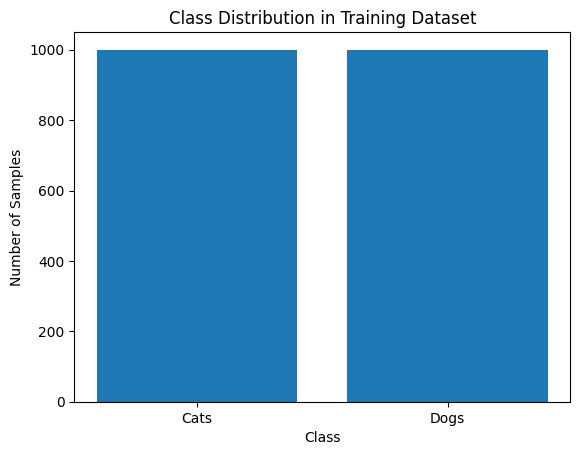

Class Distribution in Training Dataset: {'Cats': 1000, 'Dogs': 1000}


In [19]:
class_number = {"Cats": 0, "Dogs": 0}

for _, labels in train_dataset:
    class_number["Cats"] += np.sum(labels.numpy() == 0)
    class_number["Dogs"] += np.sum(labels.numpy() == 1)

plt.bar(class_number.keys(), class_number.values())
plt.title("Class Distribution in Training Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

print(f"Class Distribution in Training Dataset: {class_number}")

In [21]:
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 180, 180, 3)]     0         
                                                                 
 rescaling_2 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_10 (Conv2D)          (None, 178, 178, 32)      896       
                                                                 
 max_pooling2d_8 (MaxPoolin  (None, 89, 89, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_11 (Conv2D)          (None, 87, 87, 64)        18496     
                                                                 
 max_pooling2d_9 (MaxPoolin  (None, 43, 43, 64)        0         
 g2D)                                                      

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/15
63/63 [==============================] - 44s 679ms/step - loss: 0.7412 - accuracy: 0.5050 - val_loss: 0.6892 - val_accuracy: 0.5000
Epoch 2/15
63/63 [==============================] - 41s 655ms/step - loss: 0.6845 - accuracy: 0.5460 - val_loss: 0.6981 - val_accuracy: 0.5320
Epoch 3/15
63/63 [==============================] - 43s 683ms/step - loss: 0.6605 - accuracy: 0.6055 - val_loss: 0.6272 - val_accuracy: 0.6400
Epoch 4/15
63/63 [==============================] - 37s 580ms/step - loss: 0.6186 - accuracy: 0.6525 - val_loss: 0.7325 - val_accuracy: 0.5960
Epoch 5/15
63/63 [==============================] - 40s 637ms/step - loss: 0.5822 - accuracy: 0.7035 - val_loss: 0.6061 - val_accuracy: 0.6620
Epoch 6/15
63/63 [==============================] - 40s 643ms/step - loss: 0.5421 - accuracy: 0.7215 - val_loss: 0.5768 - val_accuracy: 0.6960
Epoch 7/15
63/63 [==============================] - 45s 72

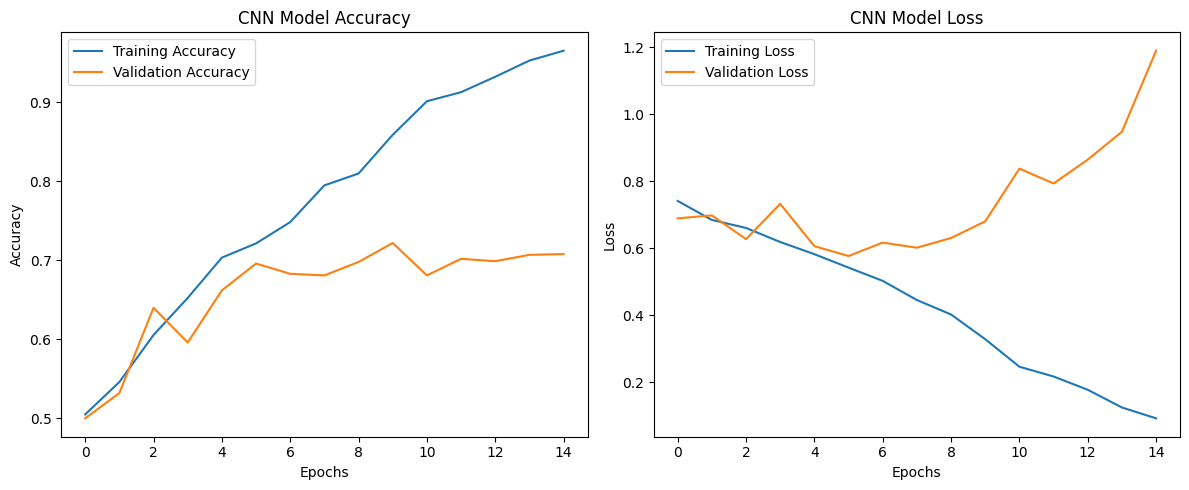

In [27]:

new_base_dir = pathlib.Path("data/kaggle_dogs_vs_cats_small")
train_dir = new_base_dir / 'train'
validation_dir = new_base_dir / 'validation'
train_datagen = ImageDataGenerator(rescale=1.0/255)
validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

validation_generator = validation_datagen.flow_from_directory(
    validation_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

#CNN model
model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_cnn = ModelCheckpoint('cnn_best_model.h5', save_best_only=True, monitor='val_accuracy', mode='max')

history_cnn = model_cnn.fit(
    train_generator,
    epochs=15,  
    validation_data=validation_generator,
    callbacks=[checkpoint_cnn]  
)

# Plot training history 
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()

Epoch 1/15
63/63 [==============================] - ETA: 0s - loss: 0.5862 - accuracy: 0.7250

c:\Users\Jimit\Documents\Class\CSCN8010_classwork\myenv\lib\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


63/63 [==============================] - 267s 4s/step - loss: 0.5862 - accuracy: 0.7250 - val_loss: 0.3099 - val_accuracy: 0.8840
Epoch 2/15
63/63 [==============================] - 256s 4s/step - loss: 0.3540 - accuracy: 0.8420 - val_loss: 0.2815 - val_accuracy: 0.8960
Epoch 3/15
63/63 [==============================] - 210s 3s/step - loss: 0.3063 - accuracy: 0.8710 - val_loss: 0.2594 - val_accuracy: 0.8930
Epoch 4/15
63/63 [==============================] - 217s 3s/step - loss: 0.2796 - accuracy: 0.8990 - val_loss: 0.2442 - val_accuracy: 0.8970
Epoch 5/15
63/63 [==============================] - 209s 3s/step - loss: 0.2414 - accuracy: 0.8945 - val_loss: 0.2565 - val_accuracy: 0.8890
Epoch 6/15
63/63 [==============================] - 211s 3s/step - loss: 0.1819 - accuracy: 0.9335 - val_loss: 0.2493 - val_accuracy: 0.9030
Epoch 7/15
63/63 [==============================] - 215s 3s/step - loss: 0.1922 - accuracy: 0.9320 - val_loss: 0.2410 - val_accuracy: 0.8950
Epoch 8/15
63/63 [======

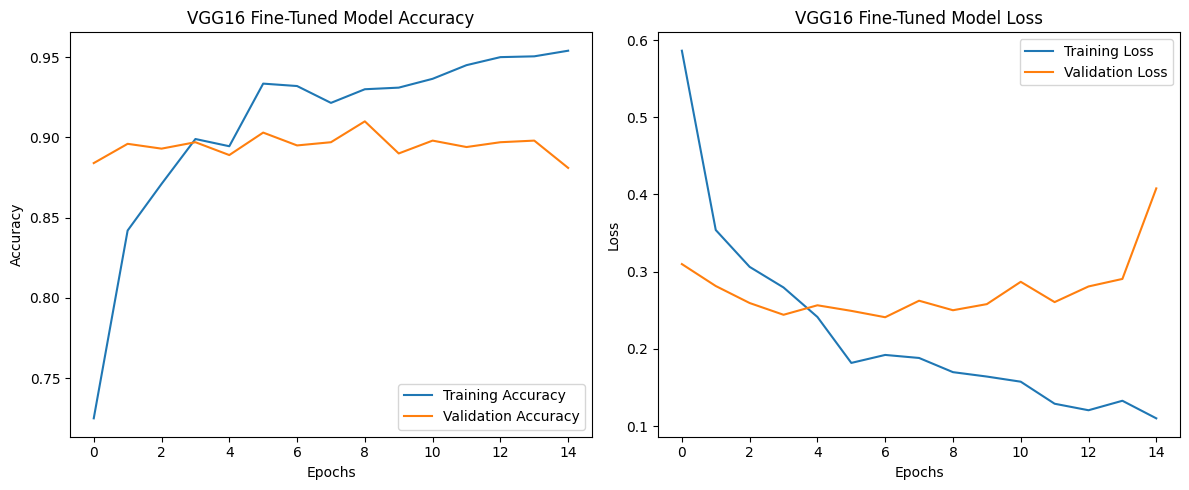

In [29]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Load VGG16 Pre-Trained Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False  

x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_vgg16 = Model(inputs=base_model.input, outputs=output)

model_vgg16.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

checkpoint_vgg16 = ModelCheckpoint('vgg16_best_model.h5', save_best_only=True, monitor='val_accuracy', mode='max')

history_vgg16 = model_vgg16.fit(
    train_generator,
    epochs=15,  
    validation_data=validation_generator,
    callbacks=[checkpoint_vgg16]
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_vgg16.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Fine-Tuned Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_vgg16.history['loss'], label='Training Loss')
plt.plot(history_vgg16.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Fine-Tuned Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Found 2000 images belonging to 2 classes.
63/63 [==============================] - 177s 3s/step
Performance Metrics for CNN Model:
Accuracy: 0.7270
Confusion Matrix:
[[755 245]
 [301 699]]
Precision: 0.7405
Recall: 0.6990
F1-Score: 0.7191


Performance Metrics for VGG16 Model:
Accuracy: 0.8790
Confusion Matrix:
[[869 131]
 [111 889]]
Precision: 0.8716
Recall: 0.8890
F1-Score: 0.8802




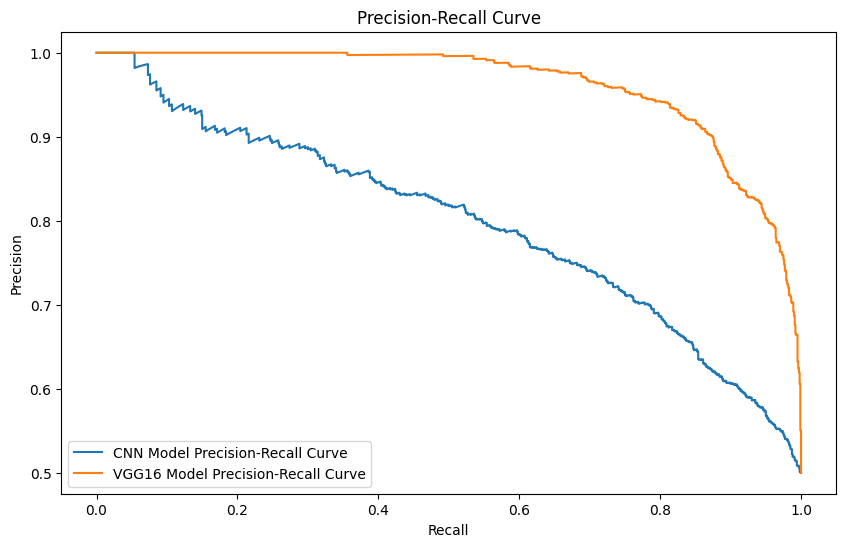


546 Misclassified Examples for CNN Model:



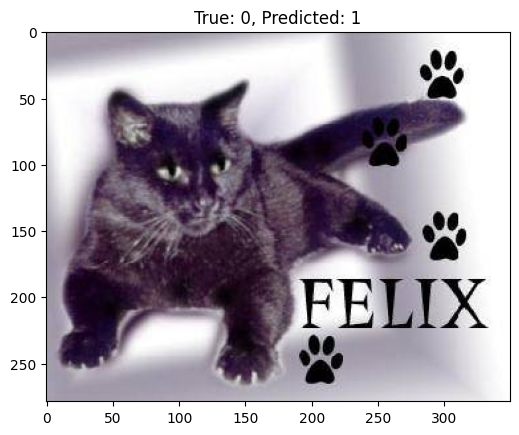

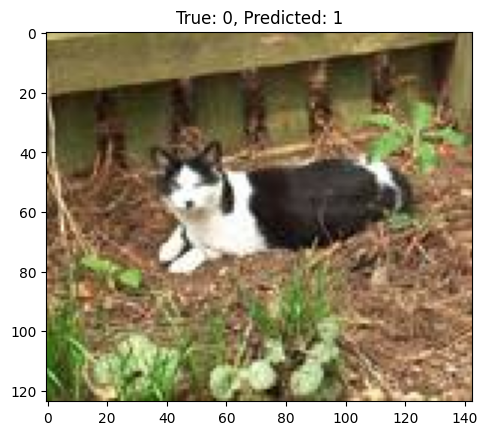

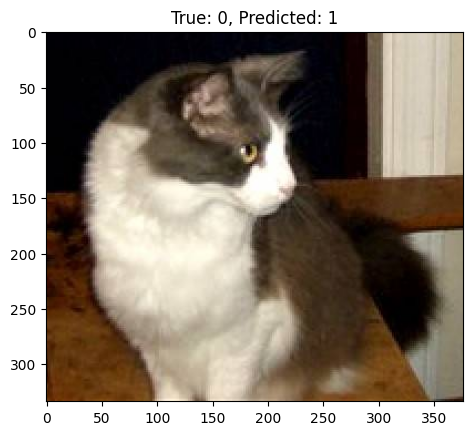

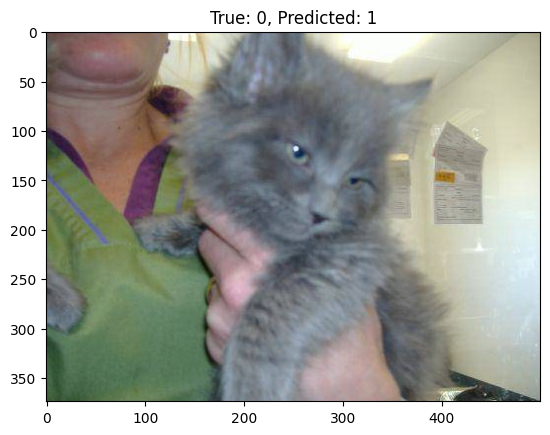

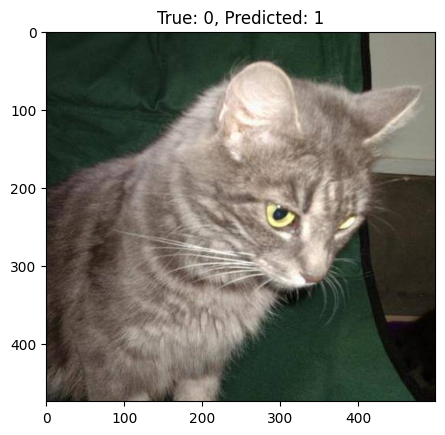


242 Misclassified Examples for VGG16 Model:



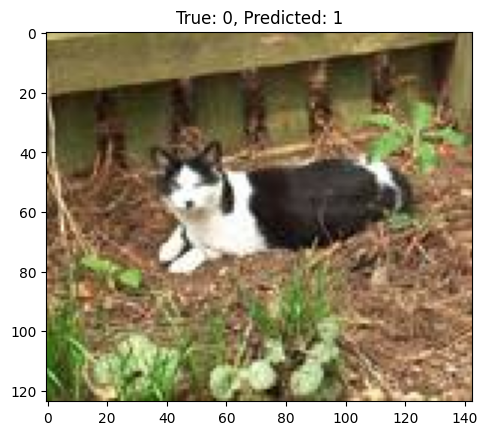

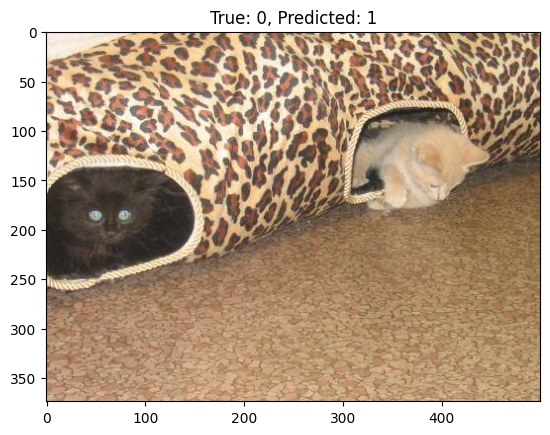

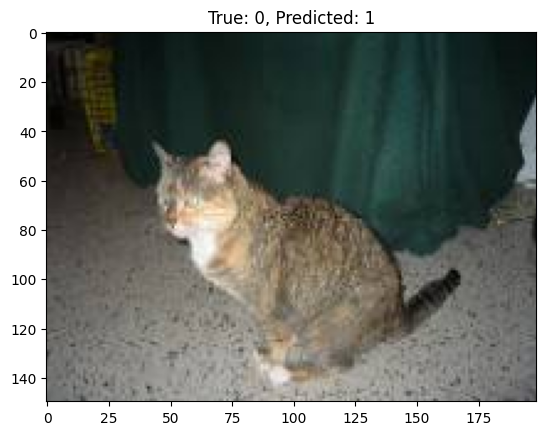

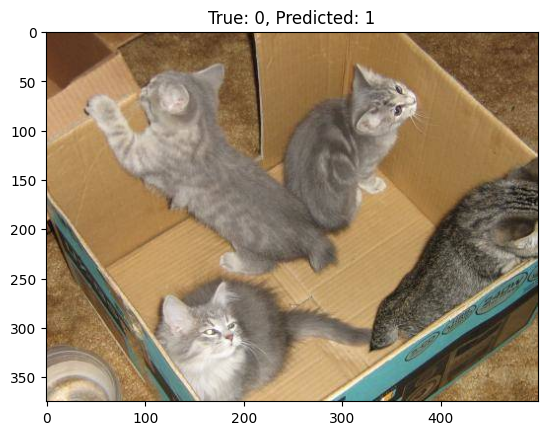

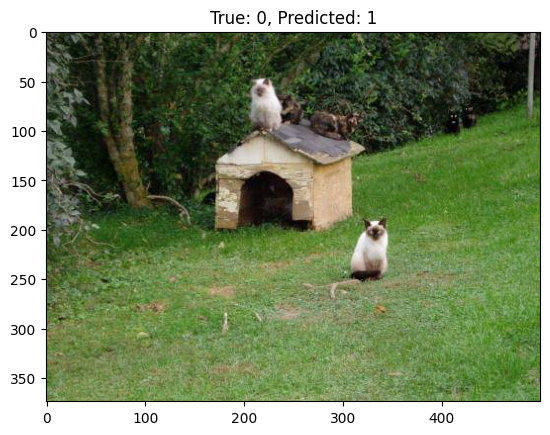

In [32]:
cnn_model = tf.keras.models.load_model('cnn_best_model.h5')
vgg16_model = tf.keras.models.load_model('vgg16_best_model.h5')

test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(
    new_base_dir / 'test',  
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False  
)

def evaluate_model(model, generator):
    probabilities = model.predict(generator)
    predictions = (probabilities > 0.5).astype(int).flatten()
    true_labels = generator.classes

    accuracy = np.mean(predictions == true_labels)

    cm = confusion_matrix(true_labels, predictions)

    precision = precision_score(true_labels, predictions)
    recall = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)

    precision_vals, recall_vals, _ = precision_recall_curve(true_labels, probabilities)

    return accuracy, cm, precision, recall, f1, precision_vals, recall_vals, true_labels, predictions

cnn_metrics = evaluate_model(cnn_model, test_generator)
vgg16_metrics = evaluate_model(vgg16_model, test_generator)

def print_results(model_name, metrics):
    accuracy, cm, precision, recall, f1, _, _, _, _ = metrics
    print(f"Performance Metrics for {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\n")

print_results("CNN Model", cnn_metrics)
print_results("VGG16 Model", vgg16_metrics)

def plot_precision_recall_curve(model_name, precision_vals, recall_vals):
    plt.plot(recall_vals, precision_vals, label=f'{model_name} Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()

plt.figure(figsize=(10, 6))
plot_precision_recall_curve("CNN Model", cnn_metrics[5], cnn_metrics[6])
plot_precision_recall_curve("VGG16 Model", vgg16_metrics[5], vgg16_metrics[6])
plt.show()

def explore_failures(model_name, generator, true_labels, predictions):
    misclassified_indices = np.where(predictions != true_labels)[0]
    print(f"\n{len(misclassified_indices)} Misclassified Examples for {model_name}:\n")

    for i in misclassified_indices[:5]:
        image_path = generator.filepaths[i]
        true_class = generator.class_indices
        plt.imshow(plt.imread(image_path))
        plt.title(f"True: {true_labels[i]}, Predicted: {predictions[i]}")
        plt.show()

explore_failures("CNN Model", test_generator, cnn_metrics[7], cnn_metrics[8])
explore_failures("VGG16 Model", test_generator, vgg16_metrics[7], vgg16_metrics[8])